# 🧪 Calibration du `hop_length` pour MFCC / Mel

Ce notebook permet de :

- Générer dynamiquement le `hop_length` optimal pour un nombre cible de frames,
- Valider les formes extraites avec `librosa.feature.mfcc()` et `melspectrogram()`,
- Visualiser les erreurs en frames et les `hop_length` à travers des heatmaps,
- Exporter un tableau de synthèse avec validation automatique.

🎯 Objectif : garantir des dimensions d'entrée stables et alignées avec les modèles profonds (ex. `(128, 344)`).


In [1]:
# 🧱 Imports de base
import sys
import warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# 🛠️ Patch de compatibilité librosa + numpy >= 1.24
if not hasattr(np, "complex"):
    np.complex = complex
    
# 📁 Ajouter dynamiquement le dossier projet au PYTHONPATH
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# 📄 Import des modules du projet
from src import config
from src.audio import audio_calibration, audio_visualization

# 🧪 Logger + décorateur de sécurité
from src.utils.logger_utils import configure_logger

# ⚙️ Configuration du logger
warnings.filterwarnings("ignore")
logger = configure_logger()
logger.info("🚀 Notebook calibration du hop_length.")

# Set seaborn style
sns.set_style("whitegrid")

# 🧾 Version de pandas
logger.info(f"✅ pandas v{pd.__version__} prêt.")


2025-04-10 00:28:06 - INFO - 🚀 Notebook calibration du hop_length.
2025-04-10 00:28:06 - INFO - ✅ pandas v2.2.3 prêt.


In [2]:
# 🎛️ Configuration globale
# 🔧 Paramètres audio
sr = int(config.SR)                  # Sampling rate, ex: 16000
n_fft = int(config.N_FFT)            # FFT window size, ex: 1024
n_mels = int(config.N_MELS)          # Nombre de bandes Mel
n_mfcc = int(config.N_MFCC)          # Nombre de coefficients MFCC
center = False                       # Padding librosa

# 🎯 Frames cibles à tester (doivent correspondre aux formes CNN souhaitées)
target_frames_list = [64, 128, 256, 344, 512]

# ⏱️ Durées audio à tester (en secondes)
durations_sec_list = [1.0, 2.0, 5.0, 10.0]

## 📊 Génération du tableau des `hop_length` optimaux

Dans ce bloc, nous utilisons `build_hop_table()` pour générer un tableau de synthèse :

- Durées testées : 1, 2, 5, 10 secondes
- Frames cibles : 64, 128, 256, 344, 512
- Pour chaque combinaison : hop_length optimal, frames réellement obtenus, et erreur relative.

Ce tableau est exploitable pour calibrer automatiquement ton prétraitement audio.


In [3]:
# 📈 Génération du tableau de calibration hop_length
df_summary = audio_calibration.build_hop_table(
    durations_sec=durations_sec_list,
    target_frames_list=target_frames_list,
    sr=sr,
    n_fft=n_fft,
    n_mfcc=n_mfcc,
    n_mels=n_mels,
    center=center,
    exact_only=False,  # ou False pour tolérance faible
    include_shapes=True 
)

# 🔍 Aperçu du tableau
#df_summary.head()


In [4]:
styled_df = audio_visualization.style_hop_table(df_summary)
display(styled_df)


,duration,target_frames,hop_length,frames_obtained,error_%,exact_match,MFCC_shape,MEL_shape,message
0,1.000000,64,244,64,0.000000,True,"(14, 64)","(64, 64)",None
1,1.000000,128,121,129,0.780000,False,"(14, 129)","(64, 129)",None
2,1.000000,256,60,259,1.170000,False,"(14, 259)","(64, 259)",None
3,1.000000,344,45,345,0.290000,False,"(14, 345)","(64, 345)",None
4,1.000000,512,30,517,0.980000,False,"(14, 517)","(64, 517)",None
5,2.000000,64,496,64,0.000000,True,"(14, 64)","(64, 64)",None
6,2.000000,128,247,128,0.000000,True,"(14, 128)","(64, 128)",None
7,2.000000,256,123,257,0.390000,False,"(14, 257)","(64, 257)",None
8,2.000000,344,91,347,0.870000,False,"(14, 347)","(64, 347)",None
9,2.000000,512,61,517,0.980000,False,"(14, 517)","(64, 517)",None


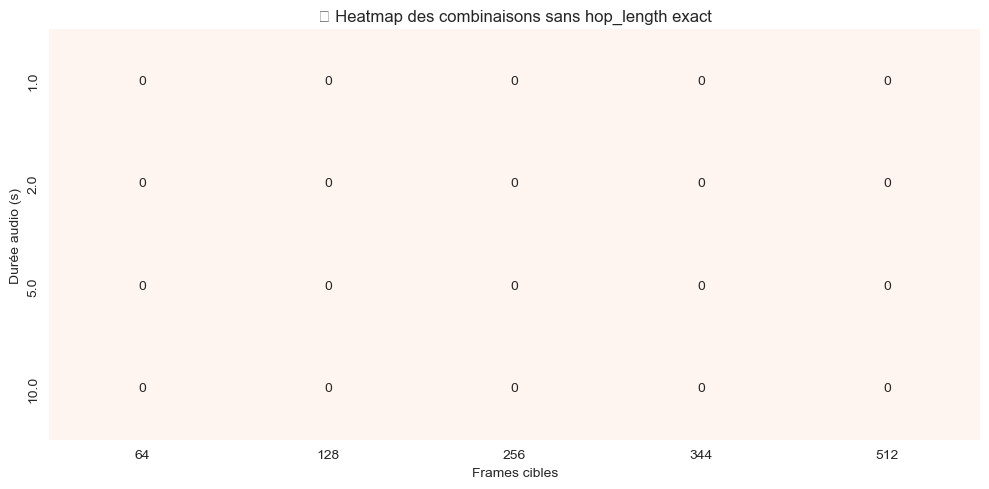

In [6]:
# 📉 Heatmap des cas sans hop_length exact (pivot_table avec agrégation)
df_failure = df_summary.copy()
df_failure["failure"] = df_failure["hop_length"].isna().astype(int)

pivot_failure = df_failure.pivot_table(
    index="duration",
    columns="target_frames",
    values="failure",
    aggfunc="max"  # ou "mean" si tu veux visualiser le taux d’échec
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_failure, cmap="Reds", annot=True, fmt=".0f", cbar=False)
plt.title("❌ Heatmap des combinaisons sans hop_length exact")
plt.xlabel("Frames cibles")
plt.ylabel("Durée audio (s)")
plt.tight_layout()
plt.show()


In [9]:
df_errors = df_summary[df_summary["message"].notnull()]
if len(df_errors):
    display(df_errors.sort_values("duration"))


In [10]:
for sec in durations_sec_list:
    n_frames = int(sr * sec)
    for target in target_frames_list:
        valid_hops = audio_calibration.compute_valid_hop_lengths(
            n_frames=n_frames,
            n_fft=n_fft,
            target_frames=target,
            center=False,
            device="cpu"
        )
        if len(valid_hops):
            print(f"Valid hops for {sec}s, {target} frames: {valid_hops}")


Valid hops for 1.0s, 64 frames: [243 244 245]
Valid hops for 2.0s, 64 frames: [493 494 495 496 497 498 499]
Valid hops for 2.0s, 128 frames: [247]
Valid hops for 5.0s, 64 frames: [1243 1244 1245 1246 1247 1248 1249 1250 1251 1252 1253 1254 1255 1256
 1257 1258 1259 1260 1261]
Valid hops for 5.0s, 128 frames: [622 623 624 625]
Valid hops for 5.0s, 256 frames: [311]
Valid hops for 10.0s, 64 frames: [2493 2494 2495 2496 2497 2498 2499 2500 2501 2502 2503 2504 2505 2506
 2507 2508 2509 2510 2511 2512 2513 2514 2515 2516 2517 2518 2519 2520
 2521 2522 2523 2524 2525 2526 2527 2528 2529 2530 2531]
Valid hops for 10.0s, 128 frames: [1247 1248 1249 1250 1251 1252 1253 1254 1255]
Valid hops for 10.0s, 256 frames: [624 625]
Valid hops for 10.0s, 344 frames: [464]
Valid hops for 10.0s, 512 frames: [312]


## 📐 Visualisation : formes MFCC et Mel spectrogramme

Ce bloc extrait et visualise les dimensions obtenues (`n_coeffs`, `n_frames`) pour :

- MFCC : `(n_mfcc, frames)`
- Mel spectrogramme : `(n_mels, frames)`

🔍 Cela permet de confirmer que le nombre de **frames est bien stable** et que les formes sont conformes au modèle attendu (ex. `(128, 344)`).


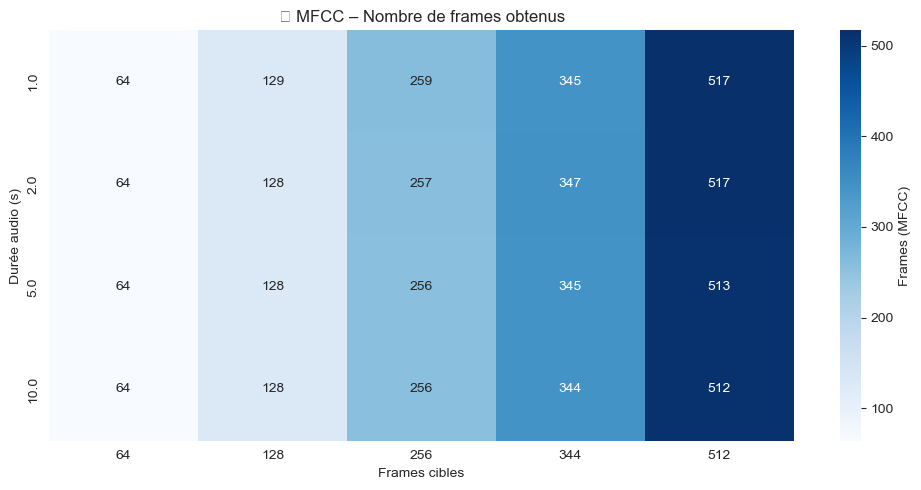

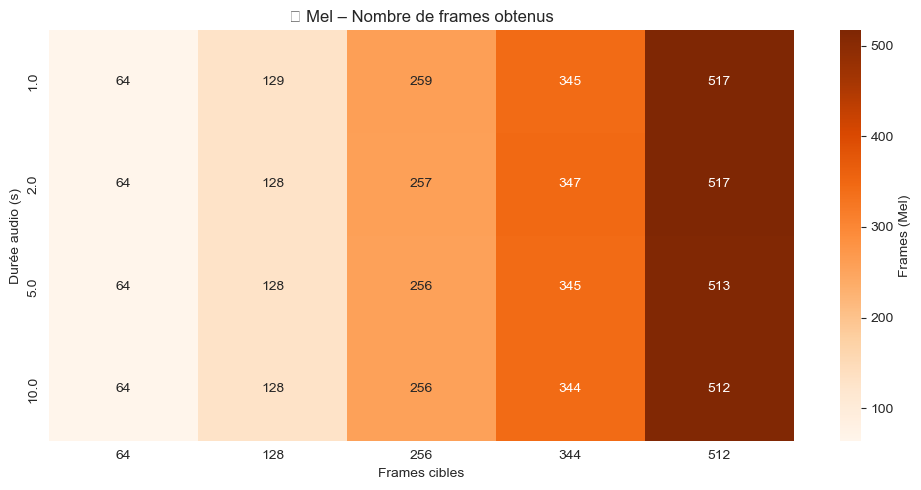

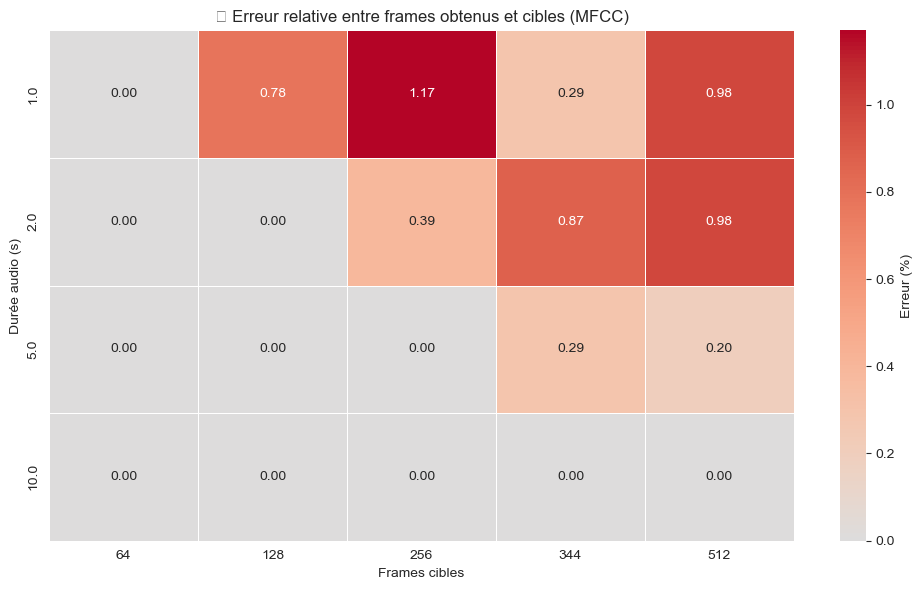

In [11]:
audio_visualization.visualize_calibration_heatmaps(df_summary)


## 🔥 Visualisation : Heatmap des erreurs de frames (en %)

Ce bloc affiche une **heatmap** qui met en évidence :

- **Les durées audio** en ligne,
- **Les frames cibles** en colonne,
- **L'erreur relative (%)** entre les frames obtenus et cibles.
- Une valeur proche de 0 indique une correspondance parfaite
- Les couleurs chaudes indiquent un écart important
- Les lignes représentent les durées d’audio (en secondes)
- Les colonnes représentent les frames cibles


🎯 L’objectif est de visualiser les zones optimales où l'erreur est minimale (en vert).
Idéal pour repérer rapidement les combinaisons stables.

## 🗺️ Visualisation : Heatmap des `hop_length` optimaux

Ce bloc affiche une heatmap montrant le `hop_length` calculé pour chaque configuration `(durée, frames cibles)`.

🎯 Objectif :
- Identifier les `hop_length` stables,
- Choisir les meilleures combinaisons `(duration, frames)` pour ton pipeline CNN ou spectrogramme.


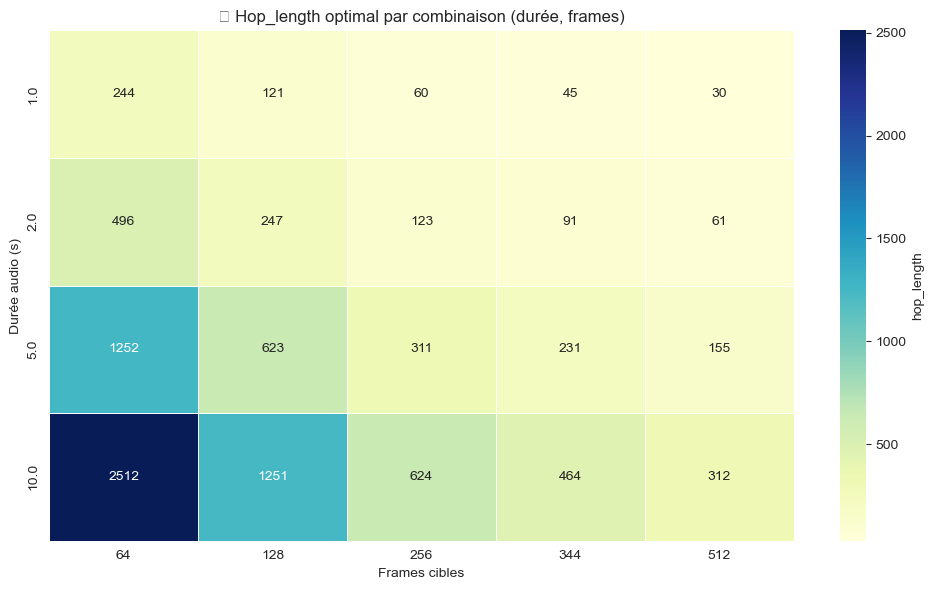

In [13]:
# 📊 Pivot table pour les hop_length
pivot_hop = df_summary.pivot(
    index="duration",
    columns="target_frames",
    values="hop_length"
)

# 📈 Heatmap hop_length
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_hop,
    annot=True, fmt="d", cmap="YlGnBu",
    linewidths=0.5, cbar_kws={'label': 'hop_length'}
)

plt.title("🧮 Hop_length optimal par combinaison (durée, frames)")
plt.xlabel("Frames cibles")
plt.ylabel("Durée audio (s)")
plt.tight_layout()
plt.show()


## 💾 Export du tableau `df_summary` au format CSV

Ce bloc enregistre le tableau généré contenant les `hop_length`, frames obtenus et erreurs pour chaque combinaison `(duration_sec, target_frames)`.

📁 Le fichier est enregistré dans `tables/hop_length_summary.csv`


In [14]:
# 📁 Répertoire d'export
output_csv = Path(config.REPORTS_DIR / "tables/hop_length_summary.csv")
output_csv.parent.mkdir(parents=True, exist_ok=True)

# 💾 Sauvegarde du tableau
df_summary.to_csv(output_csv, index=False)
logger.info(f"✅ Tableau exporté : {output_csv}")


2025-04-10 00:30:11 - INFO - ✅ Tableau exporté : C:\Users\guidy\Documents\Datascience\Projet\DCASE2024\ASD_Project_Dev\data\reports\tables\hop_length_summary.csv


## ⚠️ Cas sans correspondance exacte (`exact_match == False`)

Ce bloc permet d’inspecter les cas où le nombre de frames obtenus diffère des frames cibles.

🔍 Cela peut arriver lorsque :
- la durée n’est pas multiple du hop_length,
- ou que les paramètres `n_fft`/`center` limitent la précision.

Ces cas peuvent guider des choix de tolérance ou d’ajustement manuel.


In [15]:
# 📋 Filtrage des cas avec erreurs
df_errors = df_summary[df_summary["exact_match"] == False].copy()

if not df_errors.empty:
    display(df_errors.sort_values(by="error_%", key=lambda x: abs(x), ascending=False))
else:
    logger.info("🎉 Tous les cas ont une correspondance exacte.")


,duration,target_frames,hop_length,frames_obtained,error_%,exact_match,MFCC_shape,MEL_shape,message,MFCC_n,MFCC_frames,MEL_n,MEL_frames
2,1.0,256,60,259,1.17,False,"(14, 259)","(64, 259)",None,14,259,64,259
4,1.0,512,30,517,0.98,False,"(14, 517)","(64, 517)",None,14,517,64,517
9,2.0,512,61,517,0.98,False,"(14, 517)","(64, 517)",None,14,517,64,517
8,2.0,344,91,347,0.87,False,"(14, 347)","(64, 347)",None,14,347,64,347
1,1.0,128,121,129,0.78,False,"(14, 129)","(64, 129)",None,14,129,64,129
7,2.0,256,123,257,0.39,False,"(14, 257)","(64, 257)",None,14,257,64,257
3,1.0,344,45,345,0.29,False,"(14, 345)","(64, 345)",None,14,345,64,345
13,5.0,344,231,345,0.29,False,"(14, 345)","(64, 345)",None,14,345,64,345
14,5.0,512,155,513,0.20,False,"(14, 513)","(64, 513)",None,14,513,64,513


## 🧪 Test sur un fichier audio réel

Ce bloc permet de :

1. Charger un fichier `.wav`,
2. Appliquer le `hop_length` optimal calculé pour la durée et frames souhaités,
3. Visualiser la forme obtenue des MFCC.

🎯 Cela permet de confirmer que la fonction `get_best_hop_length()` est correcte en pratique.


2025-04-10 00:30:52 - INFO - 🎯 Hop_length = 247 | Frames obtenus = 128


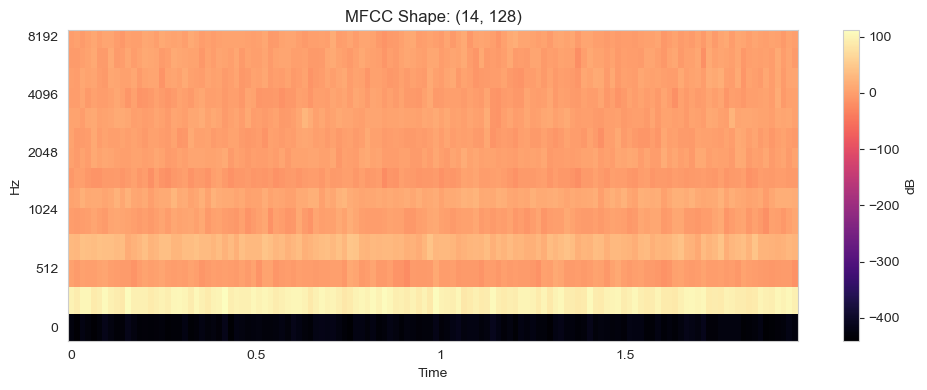

In [17]:
# 🔊 Chargement d’un fichier réel
test_audio_path = config.PROJECT_DATA_DIR / "samples/processed_audio/segment_0s_2s.wav"  # Remplacer si besoin
y, _ = librosa.load(test_audio_path, sr=sr)
duration_sec_real = len(y) / sr
target_frames = 128  # à adapter selon ton besoin

# 📐 Calcul du hop_length optimal
hop_info = audio_calibration.get_best_hop_length(
    duration=duration_sec_real,
    sr=sr,
    n_fft=n_fft,
    target_frames=target_frames,
    center=center,
    exact_only=False
)

logger.info(f"🎯 Hop_length = {hop_info['hop_length']} | Frames obtenus = {hop_info['frames_obtained']}")

# 🎛️ Extraction des MFCC
mfcc_real = librosa.feature.mfcc(
    y=y, sr=sr, n_fft=n_fft,
    hop_length=hop_info["hop_length"],
    n_mfcc=n_mfcc,
    center=center
)

# 🎨 Affichage
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc_real, sr=sr, hop_length=hop_info["hop_length"],
                         x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(label='dB')
plt.title(f"MFCC Shape: {mfcc_real.shape}")
plt.tight_layout()
plt.show()


2025-04-10 00:31:04 - INFO - 🎯 Hop_length = 496 | Frames obtenus = 64


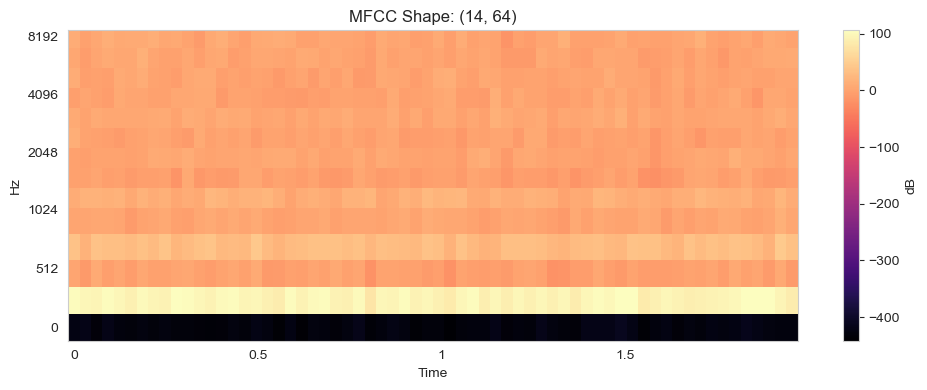

In [18]:
# 🔊 Chargement d’un fichier réel
test_audio_path = config.PROJECT_DATA_DIR / "samples/processed_audio/segment_2s_4s.wav"  # Remplacer si besoin
y, _ = librosa.load(test_audio_path, sr=sr)
duration_sec_real = len(y) / sr
target_frames = 64  # à adapter selon ton besoin

# 📐 Calcul du hop_length optimal
hop_info = audio_calibration.get_best_hop_length(
    duration=duration_sec_real,
    sr=sr,
    n_fft=n_fft,
    target_frames=target_frames,
    center=center,
    exact_only=False
)

logger.info(f"🎯 Hop_length = {hop_info['hop_length']} | Frames obtenus = {hop_info['frames_obtained']}")

# 🎛️ Extraction des MFCC
mfcc_real = librosa.feature.mfcc(
    y=y, sr=sr, n_fft=n_fft,
    hop_length=hop_info["hop_length"],
    n_mfcc=n_mfcc,
    center=center
)

# 🎨 Affichage
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc_real, sr=sr, hop_length=hop_info["hop_length"],
                         x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(label='dB')
plt.title(f"MFCC Shape: {mfcc_real.shape}")
plt.tight_layout()
plt.show()


## ✅ Synthèse finale : Calibration du `hop_length` terminée

### 🔍 Ce qui a été fait :
- Généré dynamiquement les `hop_length` pour différentes durées et frames cibles,
- Validé les dimensions extraites via MFCC / Mel spectrogrammes,
- Visualisé les erreurs (%) et valeurs de `hop_length` via des heatmaps,
- Testé la robustesse de l’approche sur un fichier `.wav` réel,
- Exporté un tableau de calibration utilisable dans tout le pipeline audio.

---

### 🧠 Mes recommandations :

- Toujours fixer **`sr`**, **`n_fft`**, **`center`** dans tout ton pipeline,
- Choisir un couple `(duration, frames)` adapté à ton modèle CNN,
- Utiliser la fonction `get_best_hop_length()` pour obtenir des features stables,
- Vérifier régulièrement les dimensions avec des extraits réels (bruit, silence, etc.),
- Exporter le tableau `df_summary` comme référence projet (`hop_length_summary.csv`).

---

In [19]:
# 🔊 Chargement d’un fichier réel
test_audio_path = Path(config.PROJECT_DATA_DIR / "samples/processed_audio/segment_2s_4s.wav")  # Remplacer si besoin
y, sr = librosa.load(test_audio_path, sr=None)
target_frames = 64  # à adapter selon ton besoin

# ✅ 1. Durée réelle de l’audio
duration_sec = len(y) // sr
# ✅ 2. Calcul du hop_length optimal pour obtenir exactement `target_frames`
try:
    hop_length = audio_calibration.get_best_hop_length_simple(
        duration=duration_sec,
        sr=sr,
        n_fft=n_fft,
        target_frames=target_frames,
        exact_only=False,
        verbose=True
    )
except ValueError as e:
    logger.warning(f"⚠️ Failed to compute valid hop_length for {test_audio_path.stem} → fallback to hop_length=512")
    hop_length = 512  # fallback
logger.info(f"🎯 Hop_length = {hop_length}")



2025-04-10 00:31:23 - INFO - 🎯 Hop_length = 496


In [20]:
# 🔊 Chargement d’un fichier réel
test_audio_path = Path(config.PROJECT_DATA_DIR / "samples/processed_audio/segment_2s_4s.wav")  # Remplacer si besoin
y, sr = librosa.load(test_audio_path, sr=None)
target_frames = 128  # à adapter selon ton besoin

# ✅ 1. Durée réelle de l’audio
duration_sec = len(y) // sr
# ✅ 2. Calcul du hop_length optimal pour obtenir exactement `target_frames`
try:
    hop_length = audio_calibration.get_best_hop_length_simple(
        duration=duration_sec,
        sr=sr,
        n_fft=n_fft,
        target_frames=target_frames,
        exact_only=False,
        verbose=True
    )
except ValueError as e:
    logger.warning(f"⚠️ Failed to compute valid hop_length for {test_audio_path.stem} → fallback to hop_length=512")
    hop_length = 512  # fallback
logger.info(f"🎯 Hop_length = {hop_length}")

2025-04-10 00:31:30 - INFO - 🎯 Hop_length = 247
